In [1]:
import pandas as pd

In [2]:
# load data in csv format to pd dataframe
ton_iot_dataset = pd.read_csv("train_test_network.csv")
simulation_dataset = pd.read_csv("dataset_training_iot.csv")
testbed_dataset = pd.read_csv("new_dataset_training_iot.csv")

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Simulation loaded: {simulation_dataset.shape}")
print(f"Testbed loaded   : {testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Simulation loaded: (36100, 47)
Testbed loaded   : (702512, 43)


In [3]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    161043
0     50000
Name: count, dtype: int64
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64

--- Simulation ---
label
1    30986
0     5114
Name: count, dtype: int64
type
injection    5769
normal       5114
ddos         5094
mitm         5086
password     5037
dos          5000
scanning     5000
Name: count, dtype: int64

--- Testbed ---
label
0    378968
1    323544
Name: count, dtype: int64
type
normal       378968
dos           78908
scanning      69603
ddos          65806
mitm          53779
password      41119
injection     14329
Name: count, dtype: int64


In [4]:
for df in [ton_iot_dataset, simulation_dataset, testbed_dataset]:
    df.replace("-", "n/a", inplace=True)
    df.drop_duplicates(inplace=True)

print(f"TON-IoT after dedup   : {ton_iot_dataset.shape}")
print(f"Simulation after dedup: {simulation_dataset.shape}")
print(f"Testbed after dedup   : {testbed_dataset.shape}")

TON-IoT after dedup   : (190474, 44)
Simulation after dedup: (13104, 47)
Testbed after dedup   : (154945, 43)


In [5]:
for name, df in [("TON-IoT", ton_iot_dataset), ("Simulation", simulation_dataset), ("Testbed", testbed_dataset)]:
    print(f"\n--- {name} ---")
    print(df['label'].value_counts())
    print(df['type'].value_counts())


--- TON-IoT ---
label
1    148434
0     42040
Name: count, dtype: int64
type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64

--- Simulation ---
label
1    12917
0      187
Name: count, dtype: int64
type
dos          4985
scanning     4613
injection    2861
ddos          195
normal        187
password      132
mitm          131
Name: count, dtype: int64

--- Testbed ---
label
1    94556
0    60389
Name: count, dtype: int64
type
normal       60389
password     27789
mitm         20979
injection    12639
dos          12201
scanning     10729
ddos         10219
Name: count, dtype: int64


In [6]:
#drop columns such as ip addressess and port numbers
DROP_COLS = ['src_ip', 'dst_ip', 'src_port', 'dst_port']

def drop_meta(df):
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

ton_iot_dataset = drop_meta(ton_iot_dataset)
simulation_dataset = drop_meta(simulation_dataset)
testbed_dataset = drop_meta(testbed_dataset)

In [7]:
all_columns = sorted(
    set(ton_iot_dataset.columns) |
    set(simulation_dataset.columns) |
    set(testbed_dataset.columns)
)

def realign_columns(df, columns):
    for c in columns:
        if c not in df.columns:
            df[c] = 'n/a'
    return df[columns]

ton_iot_dataset    = realign_columns(ton_iot_dataset,    all_columns)
simulation_dataset = realign_columns(simulation_dataset, all_columns)
testbed_dataset    = realign_columns(testbed_dataset,    all_columns)

print(f"All datasets realigned to {len(all_columns)} columns.")

All datasets realigned to 49 columns.


In [8]:
binary_columns = ["dns_query",
                  "ssl_version", "ssl_cipher", "ssl_subject", "ssl_issuer",
                  "http_uri", "http_user_agent", "http_orig_mime_types", "http_resp_mime_types",
                  "weird_name", "history", "mqtt_topic", "mqtt_qos",
                  ]

dataset_sources = {
                    "ton_iot": ton_iot_dataset,
                    "simulation": simulation_dataset,
                    "testbed": testbed_dataset,
                }

combined_dataset = pd.concat([df.assign(source=name) for name, df in dataset_sources.items()],ignore_index=True,)

dataset_counts = combined_dataset["source"].value_counts().to_dict()
print(dataset_counts)

{'ton_iot': 190474, 'testbed': 154945, 'simulation': 13104}


In [9]:
#find categorical columns not in binary_columns
categorical_columns = [c for c in combined_dataset.columns if combined_dataset[c].dtype == "object" and c not in binary_columns and c != "source"]
print(f"Categorical columns: {categorical_columns}")

#drop type column since it is redundant with label
combined_dataset.drop(columns=["type"], inplace=True)
categorical_columns.remove("type")

for col in categorical_columns + binary_columns:
    combined_dataset[col] = combined_dataset[col].astype('category')

Categorical columns: ['conn_state', 'dns_AA', 'dns_RA', 'dns_RD', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_rejected', 'http_method', 'http_request_body_len', 'http_response_body_len', 'http_trans_depth', 'http_version', 'mqtt_from_client', 'mqtt_operation', 'mqtt_payload_len', 'mqtt_retain', 'mqtt_status', 'mqtt_topic_len', 'proto', 'service', 'ssl_established', 'ssl_resumed', 'type', 'weird_addl', 'weird_notice']


In [10]:
combined_dataset = pd.get_dummies(combined_dataset, columns=categorical_columns, sparse=False)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,n/a,2592,3832,31,290.371539,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
1,n/a,0,40,1,0.000102,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
2,n/a,0,40,1,0.000148,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
3,n/a,0,40,1,0.000113,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True
4,n/a,0,40,1,0.000130,n/a,n/a,n/a,0,n/a,...,False,True,False,False,True,False,False,True,False,True


In [11]:
#apply bindary encoding
for col in binary_columns:
    combined_dataset[col] = (combined_dataset[col] != 'n/a').astype(int)

combined_dataset.head()

,dns_query,dst_bytes,dst_ip_bytes,dst_pkts,duration,history,http_orig_mime_types,http_resp_mime_types,http_status_code,http_uri,...,ssl_established_T,ssl_established_n/a,ssl_resumed_F,ssl_resumed_T,ssl_resumed_n/a,weird_addl_46,weird_addl_48,weird_addl_n/a,weird_notice_F,weird_notice_n/a
0,0,2592,3832,31,290.371539,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
1,0,0,40,1,0.000102,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
2,0,0,40,1,0.000148,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
3,0,0,40,1,0.000113,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True
4,0,0,40,1,0.000130,0,0,0,0,0,...,False,True,False,False,True,False,False,True,False,True


In [12]:
#split back into original datasets
ton_iot_dataset    = combined_dataset[combined_dataset["source"] == "ton_iot"].drop(columns=["source"])
simulation_dataset = combined_dataset[combined_dataset["source"] == "simulation"].drop(columns=["source"])
testbed_dataset    = combined_dataset[combined_dataset["source"] == "testbed"].drop(columns=["source"])

print(f"TON-IoT final shape   : {ton_iot_dataset.shape}")
print(f"Simulation final shape: {simulation_dataset.shape}")
print(f"Testbed final shape   : {testbed_dataset.shape}")

TON-IoT final shape   : (190474, 286)
Simulation final shape: (13104, 286)
Testbed final shape   : (154945, 286)


In [13]:
#split testbed into train and inference
from sklearn.model_selection import train_test_split
testbed_train, testbed_inference = train_test_split(testbed_dataset, test_size=0.5, random_state=42)

print(f"Testbed train shape   : {testbed_train.shape}")
print(f"Testbed inference shape   : {testbed_inference.shape}")

Testbed train shape   : (77472, 286)
Testbed inference shape   : (77473, 286)


In [14]:
#combine ton_iot, simulation, and testbed_train into one training dataset
train_dataset = pd.concat([ton_iot_dataset, simulation_dataset, testbed_train], ignore_index=True)

In [15]:
#apply smote to train dataset
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(train_dataset.drop(columns=["label"]), train_dataset["label"])

print(f"Train dataset before SMOTE: {X_train.shape}, {y_train.shape}")
print(f"Train dataset after SMOTE: {X_train.shape}, {y_train.shape}")

Train dataset before SMOTE: (416954, 285), (416954,)
Train dataset after SMOTE: (416954, 285), (416954,)


In [16]:
#split dataset into internal train and validation sets

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Internal train set: {X_train.shape}, {y_train.shape}")
print(f"Internal val set: {X_val.shape}, {y_val.shape}")

Internal train set: (312715, 285), (312715,)
Internal val set: (104239, 285), (104239,)


In [17]:
#load decision tree model and optimize using optuna
from sklearn.tree import DecisionTreeClassifier
import optuna
from sklearn.metrics import f1_score

#load decision tree model and optimize using optuna

def objective_dt(trial):
    param = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy','log_loss']),
        'splitter': trial.suggest_categorical('splitter', ['best', 'random']),
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'random_state': 42,
    }
    model = DecisionTreeClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=100)

[I 2026-05-03 21:12:41,497] A new study created in memory with name: no-name-deafcbfc-f322-4136-8b30-76b1cac10373
[I 2026-05-03 21:12:42,895] Trial 0 finished with value: 0.8505738368493738 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 9, 'max_features': 'sqrt', 'ccp_alpha': 0.05038303701138378}. Best is trial 0 with value: 0.8505738368493738.
[I 2026-05-03 21:12:49,457] Trial 1 finished with value: 0.9255563156412216 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 9, 'max_features': None, 'ccp_alpha': 0.04185578508049392}. Best is trial 1 with value: 0.9255563156412216.
[I 2026-05-03 21:12:50,697] Trial 2 finished with value: 0.6938705924826507 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 7, 'max_features': 'log2', 'ccp_alpha': 0.04471059856040384}. Best is trial 1 with value: 0.9255563156412216.
[I 2026-05-03 21:12:51,741] Trial 3 finished with value: 0.666662402947083 and parameters: {'criterion': '

In [18]:
import xgboost as xgb

def objective_xgb(trial):
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth',5, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.5, 2.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_leaves': trial.suggest_int('max_leaves', 1, 9),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'device': 'cuda',
        'tree_method': 'hist',
        'random_state': 42,
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

[I 2026-05-03 21:20:27,982] A new study created in memory with name: no-name-dd3b1ff2-033d-4c1d-8f76-a79a78f0e3c1
C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:774: UserWarning: [21:20:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-05-03 21:20:41,217] Trial 0 finished with value: 0.9512435827144495 and parameters: {'learning_rate': 0.29792004091213886, 'max_depth': 19, 'subsample': 0.6782034504364137, 'min_child_weight': 1.45345126

In [22]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    return f1

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

[I 2026-05-03 22:56:51,741] A new study created in memory with name: no-name-8e463de1-8aae-429e-835c-fac514efde8f
[I 2026-05-03 22:57:07,281] Trial 0 finished with value: 0.9359776201418724 and parameters: {'n_estimators': 96, 'max_depth': 9, 'max_features': 'sqrt', 'criterion': 'log_loss', 'ccp_alpha': 0.006060698511648666, 'bootstrap': True}. Best is trial 0 with value: 0.9359776201418724.
[I 2026-05-03 22:59:04,785] Trial 1 finished with value: 0.8822974248348389 and parameters: {'n_estimators': 62, 'max_depth': 7, 'max_features': None, 'criterion': 'entropy', 'ccp_alpha': 0.06974512363066078, 'bootstrap': False}. Best is trial 0 with value: 0.9359776201418724.
[I 2026-05-03 23:01:06,872] Trial 2 finished with value: 0.9090058003459855 and parameters: {'n_estimators': 51, 'max_depth': 10, 'max_features': None, 'criterion': 'entropy', 'ccp_alpha': 0.02711052244733967, 'bootstrap': False}. Best is trial 0 with value: 0.9359776201418724.
[I 2026-05-03 23:02:55,422] Trial 3 finished wit

In [23]:
#print best parameters and best score for each model
print('Decision Tree Best parameters :')
for k, v in study_dt.best_params.items():
    print(f'  {k:<22}: {v}')

print('XGBoost Best parameters :')
for k, v in study_xgb.best_params.items():
    print(f'  {k:<22}: {v}')

print('Random Forest Best parameters :')
for k, v in study_rf.best_params.items():
    print(f'  {k:<22}: {v}')

Decision Tree Best parameters :
  criterion             : log_loss
  splitter              : random
  max_depth             : 9
  max_features          : None
  ccp_alpha             : 1.0182810475696394e-05
XGBoost Best parameters :
  learning_rate         : 0.29866347458520165
  max_depth             : 9
  subsample             : 0.6725943935065807
  min_child_weight      : 1.1947649075475626
  n_estimators          : 286
  max_leaves            : 9
Random Forest Best parameters :
  n_estimators          : 91
  max_depth             : 10
  max_features          : sqrt
  criterion             : log_loss
  ccp_alpha             : 0.0003285746110382043
  bootstrap             : False


In [24]:
dt_best_params = study_dt.best_params.copy()
xgb_best_params = study_xgb.best_params.copy()
rf_best_params = study_rf.best_params.copy()

dt_model = DecisionTreeClassifier(**dt_best_params)
dt_model.fit(
    X_train, y_train,
)

dt_y_val_pred  = dt_model.predict(X_val)
dt_y_val_proba = dt_model.predict_proba(X_val)[:, 1]
print('Decision Tree Model trained.')

xgb_model = xgb.XGBClassifier(**xgb_best_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
xgb_y_val_pred  = xgb_model.predict(X_val)
xgb_y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
print('XGBoost Model trained.')

rf_model = RandomForestClassifier(**rf_best_params) 
rf_model.fit(
    X_train, y_train,
)
rf_y_val_pred  = rf_model.predict(X_val)
rf_y_val_proba = rf_model.predict_proba(X_val)[:, 1]
print('Random Forest Model trained.')

Decision Tree Model trained.
[0]	validation_0-logloss:0.49739
[50]	validation_0-logloss:0.13449
[100]	validation_0-logloss:0.11446
[150]	validation_0-logloss:0.10705
[200]	validation_0-logloss:0.10283
[250]	validation_0-logloss:0.10005
[285]	validation_0-logloss:0.09868
XGBoost Model trained.
Random Forest Model trained.


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('=== VALIDATION SET FOR DECISION TREE ===')
print(f'Accuracy  : {accuracy_score(y_val, dt_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, dt_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, dt_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, dt_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, dt_y_val_pred))
print("Classification Report:\n", classification_report(y_val, dt_y_val_pred))

=== VALIDATION SET FOR DECISION TREE ===
Accuracy  : 0.9429
Precision : 0.9810
Recall    : 0.9032
F1        : 0.9405
Confusion Matrix:
 [[51209   911]
 [ 5045 47074]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95     52120
           1       0.98      0.90      0.94     52119

    accuracy                           0.94    104239
   macro avg       0.95      0.94      0.94    104239
weighted avg       0.95      0.94      0.94    104239



In [27]:
print('=== VALIDATION SET FOR XGBOOST ===')
print(f'Accuracy  : {accuracy_score(y_val, xgb_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, xgb_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, xgb_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, xgb_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, xgb_y_val_pred))
print("Classification Report:\n", classification_report(y_val, xgb_y_val_pred))

=== VALIDATION SET FOR XGBOOST ===
Accuracy  : 0.9535
Precision : 0.9876
Recall    : 0.9185
F1        : 0.9518
Confusion Matrix:
 [[51519   601]
 [ 4246 47873]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     52120
           1       0.99      0.92      0.95     52119

    accuracy                           0.95    104239
   macro avg       0.96      0.95      0.95    104239
weighted avg       0.96      0.95      0.95    104239



In [28]:
print('=== VALIDATION SET FOR RANDOM FOREST ===')
print(f'Accuracy  : {accuracy_score(y_val, rf_y_val_pred):.4f}')
print(f'Precision : {precision_score(y_val, rf_y_val_pred):.4f}')
print(f'Recall    : {recall_score(y_val, rf_y_val_pred):.4f}')
print(f'F1        : {f1_score(y_val, rf_y_val_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_val, rf_y_val_pred))
print("Classification Report:\n", classification_report(y_val, rf_y_val_pred))

=== VALIDATION SET FOR RANDOM FOREST ===
Accuracy  : 0.9457
Precision : 0.9843
Recall    : 0.9058
F1        : 0.9434
Confusion Matrix:
 [[51367   753]
 [ 4910 47209]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     52120
           1       0.98      0.91      0.94     52119

    accuracy                           0.95    104239
   macro avg       0.95      0.95      0.95    104239
weighted avg       0.95      0.95      0.95    104239



In [33]:
X_test, y_test = testbed_inference.drop(columns=["label"]), testbed_inference["label"]

dt_y_holdout_pred  = dt_model.predict(X_test)
dt_y_holdout_proba = dt_model.predict_proba(X_test)[:, 1]

print('===DECISION TREE TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, dt_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, dt_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, dt_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, dt_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, dt_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, dt_y_holdout_pred))

===DECISION TREE TEST SET PERFORMANCE===
Accuracy  : 0.7560
Precision : 0.9993
Recall    : 0.6019
F1        : 0.7513
Confusion Matrix:
 [[30024    19]
 [18881 28549]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76     30043
           1       1.00      0.60      0.75     47430

    accuracy                           0.76     77473
   macro avg       0.81      0.80      0.76     77473
weighted avg       0.85      0.76      0.75     77473



In [34]:
xgb_y_holdout_pred  = xgb_model.predict(X_test)
xgb_y_holdout_proba = xgb_model.predict_proba(X_test)[:, 1]

print('===XGBOOST TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, xgb_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, xgb_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, xgb_y_holdout_pred))

===XGBOOST TEST SET PERFORMANCE===
Accuracy  : 0.7769
Precision : 0.9656
Recall    : 0.6591
F1        : 0.7834
Confusion Matrix:
 [[28931  1112]
 [16171 31259]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.96      0.77     30043
           1       0.97      0.66      0.78     47430

    accuracy                           0.78     77473
   macro avg       0.80      0.81      0.78     77473
weighted avg       0.84      0.78      0.78     77473



In [35]:
rf_y_holdout_pred  = rf_model.predict(X_test)
rf_y_holdout_proba = rf_model.predict_proba(X_test)[:, 1]

print('===RANDOM FOREST TEST SET PERFORMANCE===')
print(f'Accuracy  : {accuracy_score(y_test, rf_y_holdout_pred):.4f}')
print(f'Precision : {precision_score(y_test, rf_y_holdout_pred):.4f}')
print(f'Recall    : {recall_score(y_test, rf_y_holdout_pred):.4f}')
print(f'F1        : {f1_score(y_test, rf_y_holdout_pred):.4f}')
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_y_holdout_pred))
print("Classification Report:\n", classification_report(y_test, rf_y_holdout_pred))

===RANDOM FOREST TEST SET PERFORMANCE===
Accuracy  : 0.7566
Precision : 0.9998
Recall    : 0.6026
F1        : 0.7520
Confusion Matrix:
 [[30038     5]
 [18849 28581]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76     30043
           1       1.00      0.60      0.75     47430

    accuracy                           0.76     77473
   macro avg       0.81      0.80      0.76     77473
weighted avg       0.85      0.76      0.76     77473



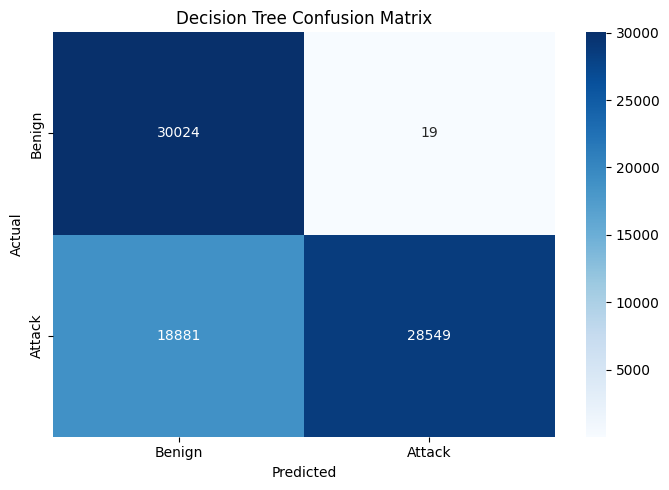

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

dt_cm = confusion_matrix(y_test, dt_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('Decision Tree Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=150)
plt.show()

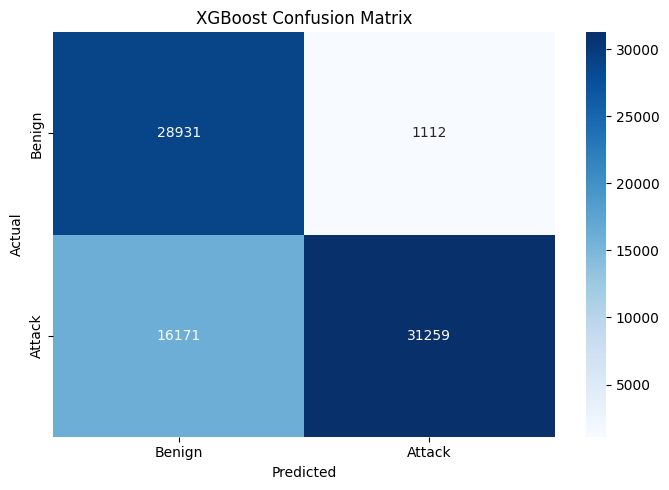

In [42]:
xgb_cm = confusion_matrix(y_test, xgb_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('XGBoost Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

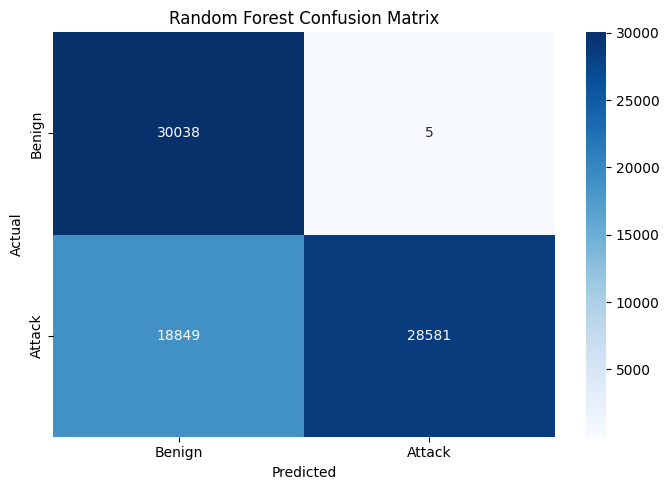

In [43]:
rf_cm = confusion_matrix(y_test, rf_y_holdout_pred)

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
axes.set_title('Random Forest Confusion Matrix')
axes.set_ylabel('Actual'); axes.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

In [45]:
import json
import joblib

#save best parameters for each model in separate json files
with open('dt_best_params.json', 'w') as f:
    json.dump(dt_best_params, f, indent=4)
print("dt_best_params.json saved.")
with open('xgb_best_params.json', 'w') as f:
    json.dump(xgb_best_params, f, indent=4)
print("xgb_best_params.json saved.")
with open('rf_best_params.json', 'w') as f:
    json.dump(rf_best_params, f, indent=4)
print("rf_best_params.json saved.")

#save each model as pkl file using joblib
joblib.dump(dt_model, 'dt_final.pkl')
print("dt_final.pkl saved.")
joblib.dump(xgb_model, 'xgb_final.pkl')
print("xgb_final.pkl saved.")
joblib.dump(rf_model, 'rf_final.pkl')
print("rf_final.pkl saved.")

#save all column names used in training as json file
with open('model_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f, indent=4)
print("model_columns.json saved.")


dt_best_params.json saved.
xgb_best_params.json saved.
rf_best_params.json saved.
dt_final.pkl saved.
xgb_final.pkl saved.
rf_final.pkl saved.
model_columns.json saved.
